# Project 1

## Question 1?

What are the most demanded skills for Data Analysts?

In [3]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [63]:
import seaborn as sns

In [10]:
df_SRB = df[df["job_country"] == "Serbia"]
df_skilss = df_SRB.explode("job_skills")

In [21]:
df_skilss[["job_title_short", "job_skills"]]
df_skilss_count = df_skilss.groupby(["job_skills", "job_title_short"]).size()
df_skilss_count = df_skilss_count.reset_index(name="count of skills").sort_values(by="count of skills", ascending=False)

In [22]:
df_skilss_count

,job_skills,job_title_short,count of skills
546,sql,Data Engineer,108
545,sql,Data Analyst,105
425,python,Data Engineer,101
39,aws,Software Engineer,92
235,java,Software Engineer,92
...,...,...,...
498,scikit-learn,Senior Data Engineer,1
226,hugging face,Machine Learning Engineer,1
500,seaborn,Senior Data Engineer,1
501,selenium,Business Analyst,1


In [36]:
job_titles = df_skilss_count["job_title_short"].unique().tolist()
job_titles = sorted(job_titles)
job_titles = sorted(job_titles[2:5])
job_titles


['Data Analyst', 'Data Engineer', 'Data Scientist']

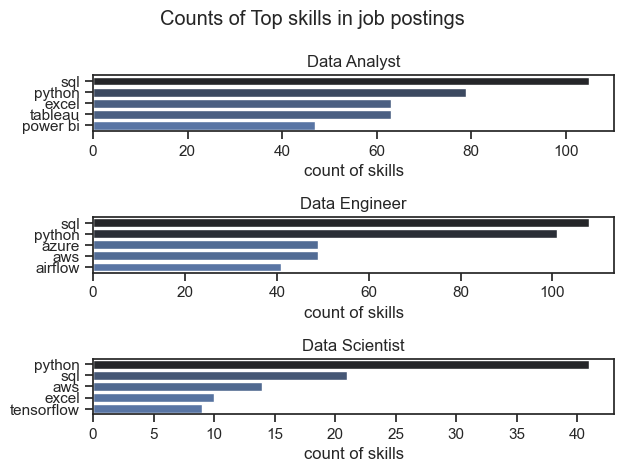

In [91]:
fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skilss_count[df_skilss_count["job_title_short"] == job_title].head(5)
    #df_plot.plot(kind="barh", x="job_skills", y="count of skills", ax=ax[i], title = job_title)
    sns.barplot(data=df_plot, x="count of skills", y="job_skills", ax=ax[i],  hue="count of skills", palette="dark:b_r")
    #ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].set_title(job_title)
    ax[i].legend().set_visible(False)
fig.suptitle("Counts of Top skills in job postings")
fig.tight_layout()
plt.show()

In [51]:
df_job_title_count = df_SRB["job_title_short"].value_counts().reset_index(name="title_count")
df_job_title_count 

,job_title_short,title_count
0,Software Engineer,238
1,Data Analyst,195
2,Data Engineer,167
3,Business Analyst,151
4,Data Scientist,86
5,Senior Data Engineer,64
6,Cloud Engineer,43
7,Machine Learning Engineer,36
8,Senior Data Analyst,25
9,Senior Data Scientist,21


In [59]:
df_skills_perc = pd.merge(df_skilss_count, df_job_title_count, how="left", on="job_title_short")
df_skills_perc["skill_perc"] = df_skills_perc["count of skills"]/df_skills_perc["title_count"] *100

In [60]:
df_skills_perc

,job_skills,job_title_short,count of skills,title_count,skill_perc
0,sql,Data Engineer,108,167,64.670659
1,sql,Data Analyst,105,195,53.846154
2,python,Data Engineer,101,167,60.479042
3,aws,Software Engineer,92,238,38.655462
4,java,Software Engineer,92,238,38.655462
...,...,...,...,...,...
632,scikit-learn,Senior Data Engineer,1,64,1.562500
633,hugging face,Machine Learning Engineer,1,36,2.777778
634,seaborn,Senior Data Engineer,1,64,1.562500
635,selenium,Business Analyst,1,151,0.662252


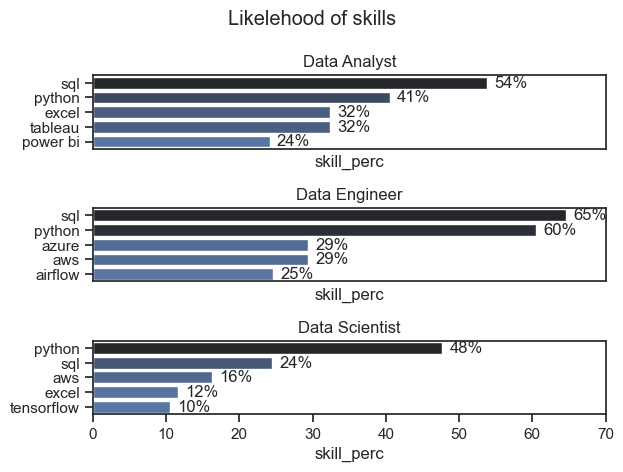

In [88]:
fig, ax = plt.subplots(len(job_titles),1)
sns.set_theme(style="ticks")

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc["job_title_short"] == job_title].head(5)
    sns.barplot(data=df_plot, x="skill_perc", y="job_skills", ax=ax[i],  hue="skill_perc", palette="dark:b_r")
    # df_plot.plot(kind="barh", x="job_skills", y="skill_perc", ax=ax[i], title = job_title)
    #ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].set_title(job_title)
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,70)

    for n,v in enumerate(df_plot["skill_perc"]):
        ax[i].text(v+1, n, f"{v:.0f}%", va="center")
    if i != len(job_titles)-1:
        ax[i].set_xticks([])

fig.suptitle("Likelehood of skills")
fig.tight_layout()
plt.show()